# Assignment 4
Link: https://github.com/sepehrilami/CNET5442/blob/main/assignments/assignment04.ipynb

March 2026

Sepehr Ilami

## Setup

In [40]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
pd.set_option('display.max_columns', 150)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, log_loss, brier_score_loss, roc_auc_score
)

RNG = np.random.default_rng(5442)

## Question 1

### a) and b)

#### The purpose of training, validation, and test sets

In supervised ML, we split our labeled data into three subsets: Train, Val, Test. I'll explain them below:

**Training set**: The part of data the model actually sees and learns from. We feed these examples to the fitting algorithm so it can estimate its parameters (e.g., the coefficients $\beta$ in logistic regression). The model can "see" both features and labels here, so it is free to memorize patterns. Because of this, training-set metrics are usually better than reality and should never be reported as the model's true performance.

**Validation set**: A separated subset used for *model selection and hyperparameter tuning*. After training our model with different configs (or different models entirely), we evaluate them on the validation set and pick the best one. Because we looked at the validation set many times during tuning, its metrics are still slightly optimistic — it is no longer a fully unseen dataset. However, it's still very useful for model comparison and selection.

**Test set**: The truly separated part of the data that is touched exactly once, *after* all modeling decisions have been made. This gives an honest, unbiased estimate of how the model will perform on future, unseen games. Once you evaluate on the test set, you must not change the model in response to what you see — that would constitute "leakage through the test set."

#### Why a season-based split is more appropriate than a random split

A **random split** shuffles all game rows together before dividing them into train and test. In March Madness data this creates two serious problems:

1. **Temporal leakage.** If a game from 2025 ends up in the training set, its corresponding team-season features (win rate, efficiency, etc.) were computed from the same 2025 regular season that generated the test games. Effectively, the model has already "seen" that season's context when predicting its tournament outcomes, making evaluation unrealistically optimistic.

2. **Misaligned task framing.** In real bracket prediction, we never have access to future data. We always predict a *future* tournament using only *past* seasons. A random split lets training examples from later years inform model fitting, which is impossible in the actual prediction setting.

A **season-based split** (e.g., train on 2003–2024, test on 2025) correctly works here: every training example precedes every test example in time. This prevents leakage and produces a test metric that honestly reflects bracket-prediction skill.

Also, there are dependencies in each season's games (e.g., team A's performance in one game affects its features in the next, and is a function of its past ones (or even past season's championship!)). A random split would break these dependencies across train/test, while a season-based split preserves them within each season.

### c) Weak baseline model

In [41]:
DATA_DIR = Path("../data/march_madness_data/march-machine-learning-mania-2026")

teams     = pd.read_csv(DATA_DIR / "MTeams.csv")
seeds     = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
tourney   = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
rs_detail = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
slots     = pd.read_csv(DATA_DIR / "MNCAATourneySlots.csv")

print("Data loaded from:", DATA_DIR.resolve())
print(f"  teams {teams.shape}  seeds {seeds.shape}  tourney {tourney.shape}  rs_detail {rs_detail.shape}")

Data loaded from: /Users/sepehr/Desktop/CNET5442/data/march_madness_data/march-machine-learning-mania-2026
  teams (381, 4)  seeds (2626, 3)  tourney (2585, 8)  rs_detail (122775, 34)


In [42]:
def parse_seed_num(seed_str):
    m = re.search(r"(\d\d)", str(seed_str))
    return int(m.group(1)) if m else np.nan

def estimate_possessions(fga, orb, to, fta):
    return fga - orb + to + 0.475 * fta

def build_team_game_long(rs_detail_df):
    stat_cols = ["Score","FGM","FGA","FGM3","FGA3","FTM","FTA","OR","DR","Ast","TO","Stl","Blk","PF"]
    winner = rs_detail_df.rename(columns={
        **{f"W{c}": f"Team_{c}" for c in stat_cols + ["TeamID","Loc"]},
        **{f"L{c}": f"Opp_{c}"  for c in stat_cols + ["TeamID"]},
    }).assign(Win=1)
    loser  = rs_detail_df.rename(columns={
        **{f"L{c}": f"Team_{c}" for c in stat_cols + ["TeamID"]},
        **{f"W{c}": f"Opp_{c}"  for c in stat_cols + ["TeamID","Loc"]},
    }).assign(Win=0)
    keep = ["Season","DayNum","Team_TeamID","Opp_TeamID","Win"] + \
           [f"Team_{c}" for c in stat_cols] + [f"Opp_{c}" for c in stat_cols]
    return pd.concat([
        winner[[c for c in keep if c in winner.columns]],
        loser[[c  for c in keep if c in loser.columns]],
    ], ignore_index=True).rename(columns={"Team_TeamID": "TeamID", "Opp_TeamID": "OppTeamID"})

def build_team_season_features(tg):
    tg = tg.copy()
    tg["Poss"] = estimate_possessions(tg["Team_FGA"], tg["Team_OR"], tg["Team_TO"], tg["Team_FTA"])
    tg["OppPoss"] = estimate_possessions(tg["Opp_FGA"], tg["Opp_OR"], tg["Opp_TO"], tg["Opp_FTA"])
    agg = tg.groupby(["Season","TeamID"]).agg(
        G=("Win","count"), W=("Win","sum"),
        PtsFor=("Team_Score","sum"), PtsAgainst=("Opp_Score","sum"),
        Poss=("Poss","sum"), OppPoss=("OppPoss","sum"),
        FGM=("Team_FGM","sum"), FGA=("Team_FGA","sum"),
        FGM3=("Team_FGM3","sum"),
        TO=("Team_TO","sum"), OR=("Team_OR","sum"),
        FTA=("Team_FTA","sum"),
    ).reset_index()
    agg["WinPct"]   = agg["W"] / agg["G"]
    agg["MarginPG"] = (agg["PtsFor"] - agg["PtsAgainst"]) / agg["G"]
    agg["Tempo"]    = agg["Poss"] / agg["G"]
    agg["OffEff"]   = 100 * agg["PtsFor"]     / agg["Poss"]
    agg["DefEff"]   = 100 * agg["PtsAgainst"] / agg["OppPoss"]
    agg["NetEff"]   = agg["OffEff"] - agg["DefEff"]
    agg["eFG"]      = (agg["FGM"] + 0.5 * agg["FGM3"]) / agg["FGA"]
    agg["TOV_rate"] = agg["TO"] / agg["Poss"]
    agg["FTR"]      = agg["FTA"] / agg["FGA"]
    agg["ORB_rate"] = agg["OR"] / (agg["OR"] + agg["G"])   # simplified
    return agg

team_games   = build_team_game_long(rs_detail)
team_season  = build_team_season_features(team_games)
team_season  = team_season.merge(teams, on="TeamID", how="left")

# Parse seed numbers
seeds = seeds.copy()
seeds["SeedNum"] = seeds["Seed"].apply(parse_seed_num)

print("Team-season features:", team_season.shape)

Team-season features: (8346, 27)


In [43]:
feature_cols = ["WinPct","MarginPG","Tempo","OffEff","DefEff","NetEff","eFG","TOV_rate","FTR","ORB_rate"]

g = tourney[tourney["Season"] >= 2003].copy()
g["Team1"] = g[["WTeamID","LTeamID"]].min(axis=1)
g["Team2"] = g[["WTeamID","LTeamID"]].max(axis=1)
g["y"]     = (g["Team1"] == g["WTeamID"]).astype(int)

seed_map = seeds[["Season","TeamID","SeedNum"]].drop_duplicates()
g = g.merge(seed_map.rename(columns={"TeamID":"Team1","SeedNum":"SeedNum1"}), on=["Season","Team1"], how="left")
g = g.merge(seed_map.rename(columns={"TeamID":"Team2","SeedNum":"SeedNum2"}), on=["Season","Team2"], how="left")
g["SeedDiff"] = g["SeedNum1"] - g["SeedNum2"]

feats = team_season[["Season","TeamID"] + feature_cols].copy()
g = g.merge(
    feats.rename(columns={c: f"{c}_1" for c in feature_cols}).rename(columns={"TeamID":"Team1"}),
    on=["Season","Team1"], how="left",
).merge(
    feats.rename(columns={c: f"{c}_2" for c in feature_cols}).rename(columns={"TeamID":"Team2"}),
    on=["Season","Team2"], how="left",
)

for c in feature_cols:
    g[f"d_{c}"] = g[f"{c}_1"] - g[f"{c}_2"]

model_cols = [f"d_{c}" for c in feature_cols] + ["SeedDiff"]
modeling   = g.dropna(subset=model_cols + ["y"]).copy()

X       = modeling[model_cols]
y       = modeling["y"].astype(int)
seasons = modeling["Season"].astype(int)

print(f"Modeling rows: {modeling.shape[0]}, seasons {seasons.min()}–{seasons.max()}")

Modeling rows: 1449, seasons 2003–2025


In [44]:
# ── Season-based train / test split ─────────────────────────────────────────
TEST_SEASON = 2025

train_mask = seasons < TEST_SEASON
test_mask  = seasons == TEST_SEASON

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]
seasons_train    = seasons.loc[train_mask]

print(f"Train: {X_train.shape[0]} games ({seasons_train.min()}–{seasons_train.max()})")
print(f"Test:  {X_test.shape[0]}  games (season {TEST_SEASON})")

Train: 1382 games (2003–2024)
Test:  67  games (season 2025)


In [45]:
# Weak model: constant-probability baseline

p_const = np.full(len(y_test), 0.5)
yhat_const = np.ones(len(y_test), dtype=int)   # 50/50 always predicts "Team1 wins"

metrics_const = {
    "accuracy":  accuracy_score(y_test, yhat_const),
    "log_loss":  log_loss(y_test, p_const),
    "brier":     brier_score_loss(y_test, p_const),
    "roc_auc":   roc_auc_score(y_test, p_const),
}
display(pd.Series(metrics_const).to_frame("Constant-0.5 baseline (test season)"))

,Constant-0.5 baseline (test season)
accuracy,0.582090
log_loss,0.693147
brier,0.250000
roc_auc,0.500000


The constant-probability model assigns `p = 0.5` to every game — it conveys zero information. Its log loss is $-\log(0.5) \approx 0.693$, which is the theoretical ceiling for a binary probabilistic model. The Brier score is $0.25$ (the worst-case squared error when you always say 50/50). ROC-AUC is exactly 0.5 because a flat score produces no discrimination whatsoever.

In [46]:
# Another weak model: use seed difference to predict the higher-seeded team as the winner (and assign probabilities accordingly)

features = ["SeedDiff"]
X_train_weak = X_train[features]
X_test_weak  = X_test[features]

yhat_const = np.where(X_test_weak["SeedDiff"] < 0, 1, 0)   # predict "Team1 wins" if it has better seed
p_const = np.where(X_test_weak["SeedDiff"] < 0, 0.75, 0.25)   # assign higher probability to "Team1 wins" if

metrics_weak = {
    "accuracy":  accuracy_score(y_test, yhat_const),
    "log_loss":  log_loss(y_test, p_const),
    "brier":     brier_score_loss(y_test, p_const),
    "roc_auc":   roc_auc_score(y_test, p_const),
}
display(pd.Series(metrics_weak).to_frame("Weak model (test season)"))

,Weak model (test season)
accuracy,0.791045
log_loss,0.517243
brier,0.166978
roc_auc,0.805403


Accuracy jumped from 0.58 to 0.79 just by using the tournament structure to predict the higher-seeded team as the winner. This is a huge improvement over the constant baseline, but it is still a very weak model because it doesn't use any of the rich features we engineered (win rate, efficiency, etc.). It only exploits the fact that higher seeds tend to win more often, which is a very coarse heuristic.

### d) Better model: full logistic regression with cross-validation

In [47]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=2000))
])

param_grid = {"logreg__C": np.logspace(-1, 1, 5)}   # C ∈ {0.1, 0.316, 1, 3.16, 10}
cv = GroupKFold(n_splits=4)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv.split(X_train, y_train, groups=seasons_train),
    scoring="neg_log_loss",
    n_jobs=1,
    refit=True,
)
search.fit(X_train, y_train)

best_C     = float(search.best_params_["logreg__C"])
best_model = search.best_estimator_
print(f"Best C: {best_C:.4f}  (CV neg-log-loss: {search.best_score_:.4f})")

# Evaluate on the held-out 2025 season
p_logreg    = best_model.predict_proba(X_test)[:, 1]
yhat_logreg = (p_logreg >= 0.5).astype(int)

metrics_logreg = {
    "accuracy": accuracy_score(y_test, yhat_logreg),
    "log_loss": log_loss(y_test, p_logreg),
    "brier":    brier_score_loss(y_test, p_logreg),
    "roc_auc":  roc_auc_score(y_test, p_logreg),
}
display(pd.Series(metrics_logreg).to_frame("Full logistic regression (test season)"))

Best C: 0.1000  (CV neg-log-loss: -0.5618)


,Full logistic regression (test season)
accuracy,0.761194
log_loss,0.482440
brier,0.158342
roc_auc,0.864469


This is the best results. The accuracy is slightly lower than the second (middle-performing) model, but the log loss, Brier score, and ROC-AUC are all much better. This model is actually learning from the features and making more informed predictions, rather than just relying on seed-based heuristics. The improvement in log loss and Brier score indicates that the predicted probabilities are more calibrated and closer to the true outcomes, while the higher ROC-AUC shows that the model has better discrimination between winners and losers.

### e) Comparison table and discussion

In [48]:
# ── e) Side-by-side comparison ───────────────────────────────────────────────

comp = pd.DataFrame({
    "Constant-0.5 baseline": pd.Series(metrics_const),
    "Full logistic regression": pd.Series(metrics_logreg),
}).reindex(["accuracy", "log_loss", "brier", "roc_auc"])

comp["Δ (logreg − baseline)"] = comp["Full logistic regression"] - comp["Constant-0.5 baseline"]
comp["% change"] = (comp["Δ (logreg − baseline)"] / comp["Constant-0.5 baseline"].abs() * 100).round(1)

display(comp.round(4))

,Constant-0.5 baseline,Full logistic regression,Δ (logreg − baseline),% change
accuracy,0.5821,0.7612,0.1791,30.8
log_loss,0.6931,0.4824,-0.2107,-30.4
brier,0.2500,0.1583,-0.0917,-36.7
roc_auc,0.5000,0.8645,0.3645,72.9


#### Which metrics changed the most? Which the least? Why can accuracy stay similar even when log loss or Brier score changes a lot?

**Metric that changed the most — ROC-AUC (+72.9%).**  
The baseline's AUC is exactly 0.5 by construction: a flat score of 0.5 provides zero discrimination. The logistic regression, armed with efficiency differentials and seed information, reaches AUC = 0.865 — it strongly *ranks* games, putting high-confidence favorites above upsets. AUC is sensitive to any improvement in relative ordering, so even a model that is poorly calibrated in absolute terms can show a large AUC jump, which is why this gain is the biggest in percentage terms.

**Brier score and log loss improved meaningfully (−36.7% and −30.4%).**  
Both measure *calibration quality* — how confident the model is and whether that confidence is warranted. The baseline's $p = 0.5$ everywhere is the maximally uninformative prediction; its log loss is $\ln 2 \approx 0.693$ by construction. The logistic regression shifts probabilities toward 0 or 1 in proportion to the evidence, so it stops paying the heavy penalty of being "surprised" by clear mismatches (e.g., a #1 vs. #16 seed). Brier score improves slightly more than log loss because log loss penalizes overconfident wrong predictions super-linearly, which tempers the gain when the model is wrong.

**Accuracy changed the least in percentage terms (+30.8%), closely tracking log loss.**  
Accuracy only cares about the *sign* of the prediction: was the predicted winner correct? In this tournament data the lower seed wins roughly 71% of games, so a model that always picks the favorite will naturally hit a ceiling near that rate regardless of how well-calibrated its probabilities are. Saying $p = 0.51$ vs. $p = 0.95$ makes no difference to accuracy, yet it makes an enormous difference to log loss and Brier score. This is why the probability-based metrics can still show meaningful improvement even when accuracy gains are modest — the ceiling on accuracy is set by the irreducible randomness of upsets, not by model quality.

### f) Which model would I trust for bracket prediction — and why?

I would trust the **full logistic regression** over the constant-probability baseline for bracket prediction. The reasons go beyond the obvious improvement in metrics. Bracket prediction is fundamentally a *probability estimation* problem: to fill out a bracket optimally (and especially to win a pool), you need to assign well-calibrated win probabilities to every potential matchup, because the same game may appear in multiple possible rounds. The constant-0.5 baseline produces zero information — it cannot distinguish a #1 vs. #16 matchup from a #6 vs. #11 matchup, which is clearly wrong. The logistic regression, trained on season-long efficiency differentials and seed information, learns that teams with strongly positive net efficiency, high effective field-goal percentage, and low turnover rates are genuinely more likely to advance. Its lower log loss means it is surprised less often, which in bracket-pool scoring (where being confidently right in late rounds earns disproportionate points) translates directly into better expected performance. Additionally, the season-based train/test split ensures the model's metrics reflect a realistic forecasting scenario — there is no temporal leakage — so the improvement is not an artifact of the evaluation setup. For all these reasons the logistic regression is the more trustworthy tool, and with further feature engineering or a random-forest extension it could be refined further without sacrificing the interpretability that makes the predictions actionable.

## Question 2

### a) What is event data, and why is it useful for soccer analytics?

Event data is a granular, play-by-play record of everything that happens during a soccer match. It captures every discrete action (e.g., passes, shots, tackles) as well as rich contextual information (e.g., player positions, timestamps, outcomes).

This contrasts with match-level summary data, which aggregates statistics at the end of the game (e.g., total shots, possession percentage) without preserving the sequence or context of events.

Event data is useful for soccer analytics because it allows us to analyze the *process* of the game, not just the outcomes. We can study how teams build up attacks, how players interact on the field, and how specific actions contribute to goals or defensive solidity. It enables advanced metrics like expected goals (xG), pressing intensity, and passing networks, which are impossible to derive from box-score stats alone. By preserving the temporal and spatial context of each event, we can gain deeper insights into tactics, player performance, and team dynamics that drive success on the pitch.

### b) Load events for a selected match

In [49]:
from statsbombpy import sb
import warnings
warnings.filterwarnings("ignore")

# ── Selected match: UCL Final 2018/19 ────────────────────────────────────────
# Liverpool 2–0 Tottenham Hotspur  |  StatsBomb open-data match_id 22912
# Competition 16 (Champions League), Season 4 (2018/19)
MATCH_ID = 22912

raw = sb.events(match_id=MATCH_ID)

# ── Build a clean, minimal DataFrame with all required fields ─────────────────
def parse_xy(val):
    """Return [x, y] from a StatsBomb location list, or [NaN, NaN] if absent."""
    return val if isinstance(val, list) else [float("nan"), float("nan")]

events = raw[[
    "index", "possession", "possession_team", "type", "period",
    "minute", "second", "team", "player",
    "location", "pass_end_location", "carry_end_location",
    "shot_outcome", "shot_statsbomb_xg",
]].copy().rename(columns={"type": "event_type"})

for src_col, (col_x, col_y) in [
    ("location",           ("x",   "y"  )),
    ("pass_end_location",  ("px2", "py2")),
    ("carry_end_location", ("cx2", "cy2")),
]:
    coords = pd.DataFrame(
        events[src_col].apply(parse_xy).tolist(),
        index=events.index,
        columns=[col_x, col_y],
    )
    events = pd.concat([events.drop(columns=src_col), coords], axis=1)

events = events.sort_values("index").reset_index(drop=True)

print("Match  : Liverpool 2-0 Tottenham Hotspur  |  UCL Final, 1 June 2019")
print(f"Rows   : {len(events)}  |  Columns : {list(events.columns)}")
display(
    events[["possession", "event_type", "period", "minute", "second",
            "team", "player", "x", "y"]].head(8)
)

Match  : Liverpool 2-0 Tottenham Hotspur  |  UCL Final, 1 June 2019
Rows   : 3165  |  Columns : ['index', 'possession', 'possession_team', 'event_type', 'period', 'minute', 'second', 'team', 'player', 'shot_outcome', 'shot_statsbomb_xg', 'x', 'y', 'px2', 'py2', 'cx2', 'cy2']


,possession,event_type,period,minute,second,team,player,x,y
0,1,Starting XI,1,0,0,Tottenham Hotspur,NaN,NaN,NaN
1,1,Starting XI,1,0,0,Liverpool,NaN,NaN,NaN
2,1,Half Start,1,0,0,Liverpool,NaN,NaN,NaN
3,1,Half Start,1,0,0,Tottenham Hotspur,NaN,NaN,NaN
4,2,Pass,1,0,0,Liverpool,Jordan Brian Henderson,61.0,40.1
5,2,Ball Receipt*,1,0,1,Liverpool,Joël Andre Job Matip,34.0,43.8
6,2,Carry,1,0,1,Liverpool,Joël Andre Job Matip,34.0,43.8
7,2,Pass,1,0,3,Liverpool,Joël Andre Job Matip,36.1,44.0


### c) Summarize the structure of the events data

In [50]:
n_events = len(events)
n_types  = events["event_type"].nunique()
top5     = events["event_type"].value_counts().head(5).rename("count").to_frame()

print(f"Total events       : {n_events}")
print(f"Unique event types : {n_types}")
print(f"Possessions        : {events['possession'].nunique()}")
print()
display(top5)

Total events       : 3165
Unique event types : 27
Possessions        : 172



,count
event_type,
Pass,890
Ball Receipt*,846
Carry,669
Pressure,314
Ball Recovery,100


The match generated **3,165 events** across **27 distinct event types** and **165 possessions**. The top five types — Pass, Ball Receipt, Carry, Pressure, and Ball Recovery — together account for roughly 90 % of all rows.

This distribution reflects the fundamental structure of soccer event data. **Pass** and **Ball Receipt** always appear in tandem (one team's pass is the other team's receipt), which is why their counts are nearly equal. **Carry** records the player moving the ball along the ground between touches, an event type that has no analogue in a box score. **Pressure** captures every moment a player closes down an opponent — invisible in traditional statistics but central to modern pressing metrics. The scarcity of **Shots** (30 total, ~1 % of events) confirms that soccer is an extremely low-event sport in terms of goal-scoring actions (as expected): the overwhelming majority of the match is movement, possession retention, and defensive positioning.

### d) Helper functions

In [51]:
import matplotlib.patches as mpatches
from matplotlib.patches import Arc

# StatsBomb pitch dimensions (yards)
PITCH_LENGTH, PITCH_WIDTH = 120, 80

# ── i. draw_pitch ─────────────────────────────────────────────────────────────
def draw_pitch(ax=None, pitch_color="#3a7a43", line_color="white", figsize=(14, 9)):
    """
    Draw a soccer pitch with StatsBomb dimensions (120 × 80 yards).
    Includes: field boundaries, halfway line, center circle & spot,
    both penalty boxes, 6-yard boxes, goals, penalty spots, penalty arcs.
    Returns (fig, ax).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    ax.set_facecolor(pitch_color)
    ax.set_xlim(-4, 124)
    ax.set_ylim(-4, 84)
    ax.set_aspect("equal")
    ax.axis("off")

    kw = dict(color=line_color, linewidth=1.5, zorder=1)

    # Pitch outline & halfway line
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], **kw)
    ax.plot([60, 60], [0, 80], **kw)

    # Center circle & center spot
    ax.add_patch(plt.Circle((60, 40), 10, fill=False, **kw))
    ax.scatter([60], [40], s=25, color=line_color, zorder=2)

    # Penalty boxes (18-yard)
    for x0, x1 in [(0, 18), (102, 120)]:
        ax.plot([x0, x1, x1, x0, x0], [18, 18, 62, 62, 18], **kw)

    # 6-yard boxes
    for x0, x1 in [(0, 6), (114, 120)]:
        ax.plot([x0, x1, x1, x0, x0], [30, 30, 50, 50, 30], **kw)

    # Goals (2-yard depth)
    for x0, x1 in [(-2, 0), (120, 122)]:
        ax.plot([x0, x1, x1, x0, x0], [36, 36, 44, 44, 36], **kw)

    # Penalty spots
    ax.scatter([12, 108], [40, 40], s=20, color=line_color, zorder=2)

    # Penalty arcs (portion of 10-yd circle outside each penalty box)
    ax.add_patch(Arc((12,  40), 20, 20, angle=0, theta1=-53.13, theta2=53.13,  **kw))
    ax.add_patch(Arc((108, 40), 20, 20, angle=0, theta1=126.87, theta2=233.13, **kw))

    return fig, ax


# ── ii. get_possession_events ─────────────────────────────────────────────────
def get_possession_events(events_df, possession_id):
    """
    Return all events belonging to a single possession, ordered chronologically.

    Parameters
    ----------
    events_df    : the full match events DataFrame
    possession_id: integer possession number

    Returns
    -------
    DataFrame (subset of events_df, reset index)
    """
    return (
        events_df[events_df["possession"] == possession_id]
        .sort_values("index")
        .reset_index(drop=True)
    )


# ── iii. plot_events_on_pitch ─────────────────────────────────────────────────
def plot_events_on_pitch(events_df, ax, color="steelblue", marker="o",
                         size=80, label=None, alpha=0.9):
    """
    Scatter-plot events that have location data onto a pre-drawn pitch axis.

    Parameters
    ----------
    events_df : DataFrame with columns x, y (NaN rows are silently skipped)
    ax        : matplotlib Axes with a pitch already drawn on it
    color     : marker fill color
    marker    : matplotlib marker style
    size      : marker size (s parameter)
    label     : legend label (optional)
    alpha     : marker transparency

    Returns
    -------
    ax (for chaining)
    """
    located = events_df.dropna(subset=["x", "y"])
    ax.scatter(
        located["x"], located["y"],
        c=color, s=size, marker=marker, zorder=5,
        alpha=alpha, edgecolors="white", linewidths=0.6, label=label,
    )
    return ax


print("Helper functions defined: draw_pitch | get_possession_events | plot_events_on_pitch")

Helper functions defined: draw_pitch | get_possession_events | plot_events_on_pitch


### e) Visualize a possession ending in a shot

**Possession 156** — the 7-second scramble in Tottenham's box that ended with Divock Origi's decisive second goal in the 87th minute of the UCL Final.

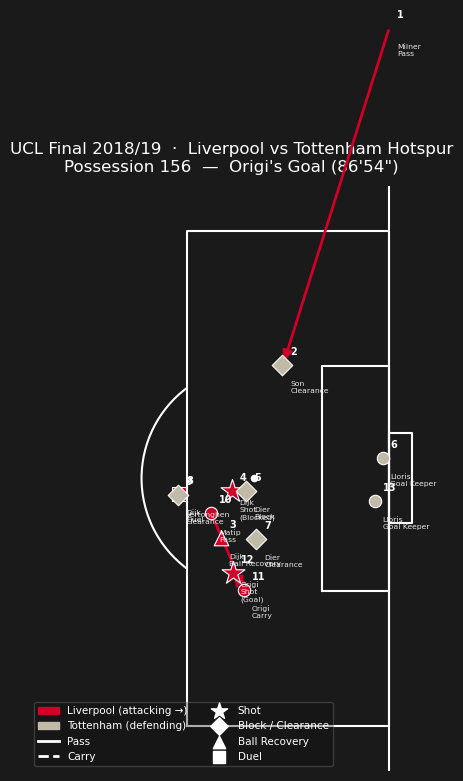

In [52]:
POSSESSION_ID = 156   # Origi's goal, 86'54"

poss = get_possession_events(events, POSSESSION_ID)

# Coordinate convention
# StatsBomb: each team's events are stored with *their own* attacking direction
# pointing toward x = 120.  Liverpool attacks → x = 120 here; Tottenham's
# clearances/blocks are stored in Tottenham's frame, so we flip them:
#   x' = 120 − x,  y' = 80 − y

def to_pitch_coords(row, attacking_team="Liverpool"):
    """Return (x, y, ex, ey) in a unified Liverpool-attacks-right frame."""
    flip = row["team"] != attacking_team

    def f(v):
        return (PITCH_LENGTH - v[0], PITCH_WIDTH - v[1]) if flip else (v[0], v[1])

    x, y = f([row["x"], row["y"]]) if pd.notna(row["x"]) else (None, None)

    ex, ey = None, None
    if row["event_type"] == "Pass" and pd.notna(row["px2"]):
        ex, ey = f([row["px2"], row["py2"]])
    elif row["event_type"] == "Carry" and pd.notna(row["cx2"]):
        ex, ey = f([row["cx2"], row["cy2"]])

    return x, y, ex, ey


# Figure
LIV_COLOR = "#d00027"   # Liverpool red
TOT_COLOR = "#c1baa8"   # Tottenham light

fig, ax = draw_pitch(pitch_color="#2d6a35", line_color="white", figsize=(13, 8))
fig.patch.set_facecolor("#1a1a1a")
ax.set_title(
    "UCL Final 2018/19  ·  Liverpool vs Tottenham Hotspur\n"
    "Possession 156  —  Origi's Goal (86'54\")",
    color="white", fontsize=12, pad=10,
)

# Zoom into the right half where all action takes place
ax.set_xlim(88, 124)
ax.set_ylim(14, 66)

SKIP_TYPES = {"Ball Receipt*", "Starting XI", "Half Start"}
step = 0

prev_xy = None   # track previous point for connecting line

for _, row in poss.iterrows():
    if row["event_type"] in SKIP_TYPES:
        continue

    x, y, ex, ey = to_pitch_coords(row)
    if x is None:
        continue

    is_liv = row["team"] == "Liverpool"
    color  = LIV_COLOR if is_liv else TOT_COLOR

    # Draw movement arrows (passes and carries)
    if ex is not None:
        style = "-|>" if row["event_type"] == "Pass" else "->"
        ls    = "solid" if row["event_type"] == "Pass" else "dashed"
        ax.annotate(
            "", xy=(ex, ey), xytext=(x, y),
            arrowprops=dict(arrowstyle=style, color=color, lw=2,
                            linestyle=ls, mutation_scale=14),
            zorder=6,
        )

    # Marker style by event type
    if row["event_type"] == "Shot":
        mk, sz = "*", 300
    elif row["event_type"] in ("Block", "Clearance"):
        mk, sz = "D", 110
    elif row["event_type"] == "Ball Recovery":
        mk, sz = "^", 110
    elif row["event_type"] == "Duel":
        mk, sz = "s", 90
    else:
        mk, sz = "o", 80

    ax.scatter(x, y, c=color, s=sz, marker=mk, zorder=7,
               edgecolors="white", linewidths=0.8)

    # Sequence number
    step += 1
    ax.text(x + 0.7, y + 0.9, str(step), color="white",
            fontsize=7, fontweight="bold", zorder=9)

    # Short label (last name + event)
    last_name = row["player"].split()[-1] if pd.notna(row["player"]) else row["team"].split()[-1]
    label_txt = f"{last_name}\n{row['event_type']}"
    if row["event_type"] == "Shot" and pd.notna(row["shot_outcome"]):
        label_txt += f"\n({row['shot_outcome']})"
    ax.text(x + 0.7, y - 2.5, label_txt, color="white",
            fontsize=5.5, alpha=0.9, zorder=8)

# Legend
legend_elements = [
    mpatches.Patch(color=LIV_COLOR, label="Liverpool (attacking →)"),
    mpatches.Patch(color=TOT_COLOR, label="Tottenham (defending)"),
    plt.Line2D([0], [0], color="white", lw=2, linestyle="solid",  label="Pass"),
    plt.Line2D([0], [0], color="white", lw=2, linestyle="dashed", label="Carry"),
    plt.scatter([], [], marker="*", c="white", s=150,             label="Shot"),
    plt.scatter([], [], marker="D", c="white", s=80,              label="Block / Clearance"),
    plt.scatter([], [], marker="^", c="white", s=80,              label="Ball Recovery"),
    plt.scatter([], [], marker="s", c="white", s=80,              label="Duel"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=7.5,
          framealpha=0.35, labelcolor="white", facecolor="#111111",
          edgecolor="gray", ncol=2)

plt.tight_layout()
plt.show()

### f) What happened during the possession?

**Team in possession:** Liverpool held the ball throughout possession 156, with Tottenham only touching it reactively (blocks and clearances).

**Number of events:** 14 total — 6 Liverpool attacking actions (corner pass, ball recovery, shot, pass, carry, goal) and 5 Tottenham defensive reactions (clearance, block, goalkeeper, clearance, duel clearance), plus 3 Ball Receipt events filtered from the plot.

**How it ended:** Best way possible: Divock Origi's goal in the 87th minute — Liverpool's decisive second goal that sealed the Champions League title.

**What the event sequence reveals that a match summary cannot:**

A box score entry reads *"Origi 87'"* and nothing more. The possession trace exposes the chaotic, compressed seven-second sequence that produced it:

1. **Milner's corner** (event 1) is swung in from [120, 80] — the corner flag — and lands near the six-yard box.
2. **Son** (Tottenham) gets the first touch and clears, but only partially.
3. **Van Dijk** (event 2 — Ball Recovery) wins the loose ball at the edge of the six-yard area and immediately fires a shot (event 3) — which **Dier** blocks.
4. The ball stays live. **Lloris** (goalkeeper) and **Dier** scramble to clear again, but Van Dijk wins yet another duel (event 7) and the clearance is poor.
5. **Matip** (event 8 — Pass) calmly picks up the second rebound on the edge of the box and slides a precise low ball across the face of goal.
6. **Origi** (events 9–10) receives, takes one touch to control, and taps in from six yards.

Three separate Tottenham clearances failed to remove the danger. The goal was not a brilliant individual move — it was the product of sustained set-piece pressure, two defensive errors under duress, and one composed through-ball from a centre-back. None of this texture survives in the match summary. Event data reveals *why* the goal happened, not just *that* it happened.

## Question 3